# WFH Burnout — 03: Threshold Analysis & Bootstrap Robustness

Derives intervention thresholds for the top features using class mean midpoints, validates statistical significance with Mann-Whitney U tests, and confirms ranking stability via 100-iteration bootstrap resampling.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}
ORDER   = ['Low', 'Medium', 'High']
BEHAVIORAL = [
    'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
    'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
    'isolation_index'
]
FEATURES = BEHAVIORAL + ['day_type_enc']
print('Libraries loaded')

Libraries loaded


In [2]:
# Load data and importance scores saved by notebook 02
df = pd.read_csv('wfh_burnout_dataset.csv')
df.drop(columns=['user_id'], inplace=True)
df['day_type_enc'] = (df['day_type'] == 'Weekday').astype(int)

lr_importance  = pd.read_csv('lr_importance.csv',  index_col=0)['importance']
rf_importance  = pd.read_csv('rf_importance.csv',  index_col=0)['importance']
svm_importance = pd.read_csv('svm_importance.csv', index_col=0)['importance']

print('Top 5 — Logistic Regression:')
print(lr_importance.head())
print('\nTop 5 — Random Forest:')
print(rf_importance.head())
print('\nTop 5 — SVM:')
print(svm_importance.head())

Top 5 — Logistic Regression:
isolation_index      3.142505
sleep_hours          2.379857
work_hours           1.114247
screen_time_hours    0.942417
meetings_count       0.367966
Name: importance, dtype: float64

Top 5 — Random Forest:
isolation_index      0.244109
sleep_hours          0.230234
work_hours           0.190431
screen_time_hours    0.159767
app_switches         0.056826
Name: importance, dtype: float64

Top 5 — SVM:
isolation_index      0.224625
sleep_hours          0.174125
work_hours           0.043625
app_switches         0.029250
screen_time_hours    0.026875
Name: importance, dtype: float64


In [3]:
# Consensus ranking — average rank position across all three models
rank_df = pd.DataFrame({
    'LR Rank' : lr_importance.rank(ascending=False),
    'RF Rank' : rf_importance.rank(ascending=False),
    'SVM Rank': svm_importance.rank(ascending=False),
})
rank_df['Mean Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Mean Rank')

display(rank_df.round(2))

TOP_FEATURES = rank_df.head(4).index.tolist()
print(f'Top 4 features for threshold analysis: {TOP_FEATURES}')

,LR Rank,RF Rank,SVM Rank,Mean Rank
isolation_index,1.0,1.0,1.0,1.00
sleep_hours,2.0,2.0,2.0,2.00
work_hours,3.0,3.0,3.0,3.00
screen_time_hours,4.0,4.0,5.0,4.33
app_switches,7.0,5.0,4.0,5.33
meetings_count,5.0,6.0,6.0,5.67
breaks_taken,8.0,8.0,7.0,7.67
after_hours_work,6.0,9.0,10.0,8.33
task_completion,9.0,7.0,9.0,8.33
day_type_enc,10.0,10.0,8.0,9.33


Top 4 features for threshold analysis: ['isolation_index', 'sleep_hours', 'work_hours', 'screen_time_hours']


In [4]:
# Pairwise Mann-Whitney U tests — validates that each top feature's distribution
# is significantly different between every pair of burnout risk classes
pairs = [('Low', 'Medium'), ('Low', 'High'), ('Medium', 'High')]
results = []

for feat in TOP_FEATURES:
    for cls_a, cls_b in pairs:
        group_a = df[df['burnout_risk'] == cls_a][feat].values
        group_b = df[df['burnout_risk'] == cls_b][feat].values
        stat, p = mannwhitneyu(group_a, group_b, alternative='two-sided')
        results.append({
            'Feature'    : feat,
            'Comparison' : f'{cls_a} vs {cls_b}',
            'U-statistic': round(stat, 2),
            'p-value'    : f'{p:.2e}',
            'Significant': 'Yes' if p < 0.05 else 'No'
        })

mw_df = pd.DataFrame(results)
display(mw_df)

,Feature,Comparison,U-statistic,p-value,Significant
0,isolation_index,Low vs Medium,99671.5,2.69e-188,Yes
1,isolation_index,Low vs High,1191.5,2.77e-87,Yes
2,isolation_index,Medium vs High,26698.5,2.55e-25,Yes
3,sleep_hours,Low vs Medium,726091.0,1.85e-145,Yes
4,sleep_hours,Low vs High,140264.5,2.06e-80,Yes
5,sleep_hours,Medium vs High,103962.0,7.81e-50,Yes
6,work_hours,Low vs Medium,236473.5,1.01e-62,Yes
7,work_hours,Low vs High,169.0,7.81e-81,Yes
8,work_hours,Medium vs High,12251.5,4.37e-50,Yes
9,screen_time_hours,Low vs Medium,235694.5,3.25e-63,Yes


In [5]:
# Intervention threshold derivation
# Threshold = midpoint between Low and High class means
# Direction indicates whether values above or below the threshold signal higher risk
threshold_results = []

for feat in TOP_FEATURES:
    low_mean  = df[df['burnout_risk'] == 'Low'][feat].mean()
    med_mean  = df[df['burnout_risk'] == 'Medium'][feat].mean()
    high_mean = df[df['burnout_risk'] == 'High'][feat].mean()
    threshold = (low_mean + high_mean) / 2

    threshold_results.append({
        'Feature'    : feat,
        'Low Mean'   : round(low_mean,  2),
        'Medium Mean': round(med_mean,  2),
        'High Mean'  : round(high_mean, 2),
        'Threshold'  : round(threshold, 2),
        'Direction'  : 'Above threshold = higher risk' if high_mean > low_mean
                       else 'Below threshold = higher risk'
    })

thresh_df = pd.DataFrame(threshold_results)
display(thresh_df)
thresh_df.to_csv('thresholds.csv', index=False)
print('Saved: thresholds.csv')

print('\nActionable Interpretations:')
for _, row in thresh_df.iterrows():
    print(f"  {row['Feature']:20s}: threshold = {row['Threshold']}  ({row['Direction']})")

,Feature,Low Mean,Medium Mean,High Mean,Threshold,Direction
0,isolation_index,3.76,5.85,7.18,5.47,Above threshold = higher risk
1,sleep_hours,7.49,6.47,5.07,6.28,Below threshold = higher risk
2,work_hours,8.13,9.44,12.10,10.12,Above threshold = higher risk
3,screen_time_hours,6.75,8.23,11.29,9.02,Above threshold = higher risk


Saved: thresholds.csv

Actionable Interpretations:
  isolation_index     : threshold = 5.47  (Above threshold = higher risk)
  sleep_hours         : threshold = 6.28  (Below threshold = higher risk)
  work_hours          : threshold = 10.12  (Above threshold = higher risk)
  screen_time_hours   : threshold = 9.02  (Above threshold = higher risk)


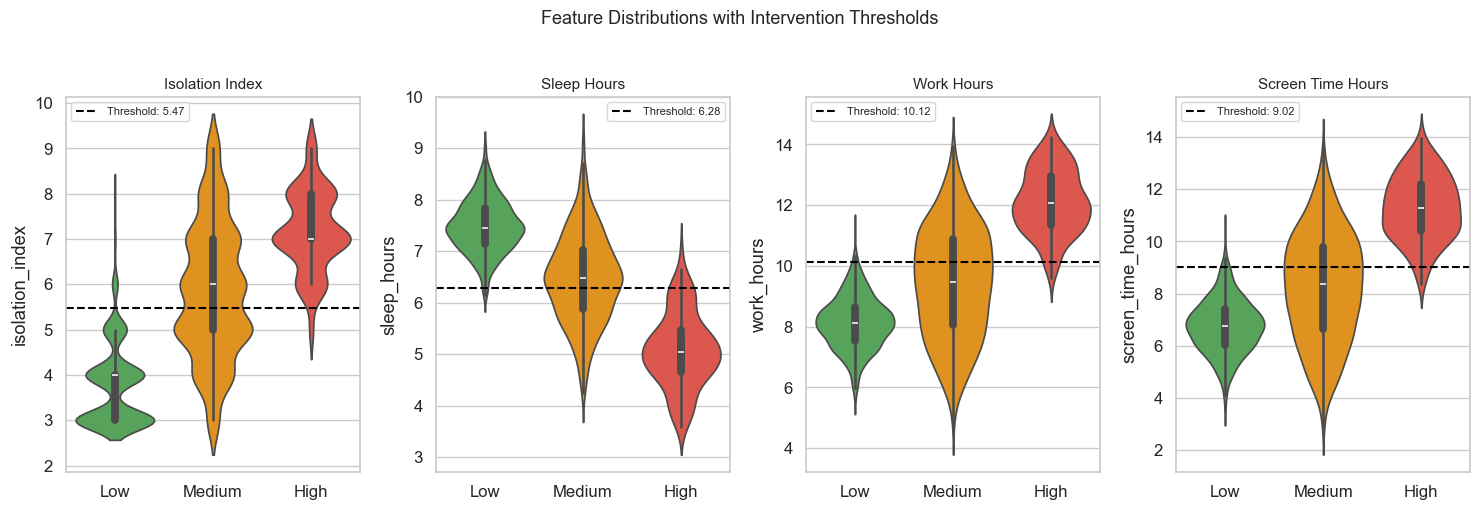

Saved: fig_08_threshold_violins.png


In [6]:
# Violin plots with threshold lines — shows full distribution shape per class
# Violin plots reveal distribution shape beyond what box plots show
fig, axes = plt.subplots(1, len(TOP_FEATURES), figsize=(15, 5))

for i, row in thresh_df.iterrows():
    ax = axes[i]
    sns.violinplot(data=df, x='burnout_risk', y=row['Feature'],
                   order=ORDER, palette=PALETTE, ax=ax)
    ax.axhline(y=row['Threshold'], color='black', linestyle='--',
               linewidth=1.5, label=f"Threshold: {row['Threshold']}")
    ax.set_title(row['Feature'].replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions with Intervention Thresholds', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_08_threshold_violins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_08_threshold_violins.png')

In [7]:
# Bootstrap robustness — 100 iterations of resampling with replacement
# Confirms that feature importance rankings are not artifacts of a single split
N_BOOTSTRAP = 100
bootstrap_records = []

print(f'Running {N_BOOTSTRAP} bootstrap iterations...')
for i in tqdm(range(N_BOOTSTRAP)):
    sample = df.sample(n=len(df), replace=True, random_state=i)
    X_s    = sample[FEATURES]
    y_s    = sample['burnout_risk']
    rf     = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=i)
    rf.fit(X_s, y_s)
    bootstrap_records.append(dict(zip(FEATURES, rf.feature_importances_)))

bootstrap_df = pd.DataFrame(bootstrap_records)
boot_summary = pd.DataFrame({
    'Mean Importance' : bootstrap_df.mean(),
    'CI Lower (2.5%)' : bootstrap_df.quantile(0.025),
    'CI Upper (97.5%)': bootstrap_df.quantile(0.975),
}).sort_values('Mean Importance', ascending=False).round(4)

display(boot_summary)
boot_summary.to_csv('bootstrap_importance.csv')
print('Saved: bootstrap_importance.csv')

Running 100 bootstrap iterations...


100%|██████████| 100/100 [00:17<00:00,  5.61it/s]


,Mean Importance,CI Lower (2.5%),CI Upper (97.5%)
sleep_hours,0.2389,0.1999,0.2795
isolation_index,0.2252,0.1975,0.2495
work_hours,0.1821,0.1486,0.2132
screen_time_hours,0.1632,0.1254,0.2026
app_switches,0.0660,0.0533,0.0820
meetings_count,0.0510,0.0398,0.0635
task_completion,0.0453,0.0348,0.0586
breaks_taken,0.0177,0.0138,0.0238
after_hours_work,0.0061,0.0040,0.0100
day_type_enc,0.0043,0.0034,0.0053


Saved: bootstrap_importance.csv


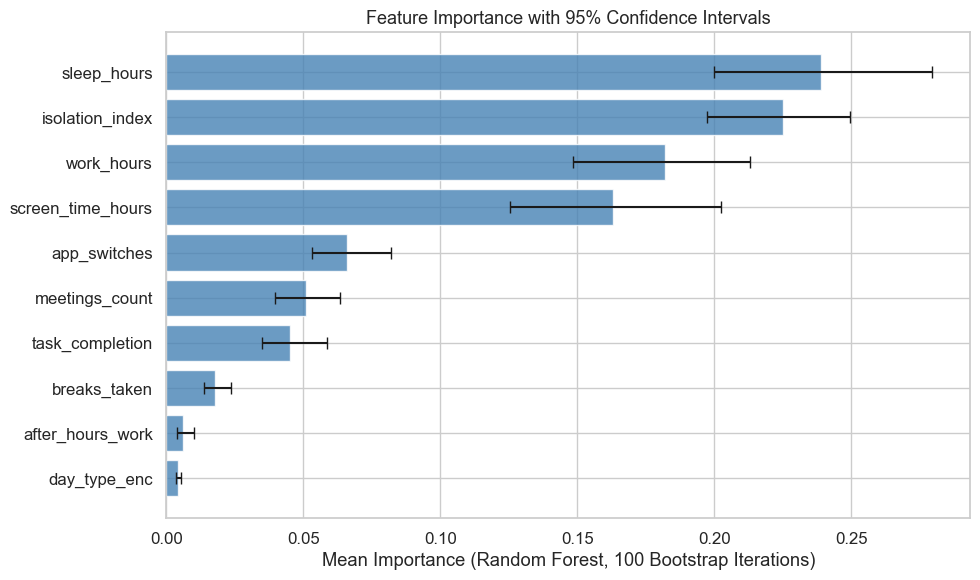

Saved: fig_09_bootstrap_importance.png


In [8]:
# Bootstrap bar chart with 95% confidence interval error bars
fig, ax = plt.subplots(figsize=(10, 6))
means     = boot_summary['Mean Importance']
xerr_low  = means - boot_summary['CI Lower (2.5%)']
xerr_high = boot_summary['CI Upper (97.5%)'] - means
ax.barh(boot_summary.index, means, xerr=[xerr_low, xerr_high],
        capsize=4, color='steelblue', alpha=0.8)
ax.set_xlabel('Mean Importance (Random Forest, 100 Bootstrap Iterations)')
ax.set_title('Feature Importance with 95% Confidence Intervals', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('fig_09_bootstrap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_09_bootstrap_importance.png')

In [9]:
# Summary
print('='*65)
print('NOTEBOOK 03 SUMMARY')
print('='*65)
print(f'Top features: {TOP_FEATURES}')
print('\nIntervention Thresholds:')
for _, row in thresh_df.iterrows():
    print(f"  {row['Feature']:20s}: {row['Threshold']}  —  {row['Direction']}")
print(f'\nBootstrap iterations : {N_BOOTSTRAP}')
print(f'Most important (boot): {boot_summary["Mean Importance"].idxmax()}')
print('='*65)

NOTEBOOK 03 SUMMARY
Top features: ['isolation_index', 'sleep_hours', 'work_hours', 'screen_time_hours']

Intervention Thresholds:
  isolation_index     : 5.47  —  Above threshold = higher risk
  sleep_hours         : 6.28  —  Below threshold = higher risk
  work_hours          : 10.12  —  Above threshold = higher risk
  screen_time_hours   : 9.02  —  Above threshold = higher risk

Bootstrap iterations : 100
Most important (boot): sleep_hours
